# DEG Analysis — CellTypist Low (fine-grained) Cell Types
Differential expression across all 14 cell types annotated by `Immune_All_Low.pkl`.

## 1. Imports & settings

In [1]:
import warnings
warnings.filterwarnings('ignore')

import scanpy as sc
import pandas as pd

sc.settings.verbosity = 1
sc.settings.set_figure_params(dpi=100, frameon=False)

## 2. Load data

In [2]:
adata = sc.read_h5ad('bone_marrow_celltypist.h5ad')
adata

AnnData object with n_obs × n_vars = 16828 × 23427
    obs: 'sample', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'n_genes', 'doublet_score', 'predicted_doublet', 'leiden', 'celltypist_low', 'celltypist_high'
    var: 'mt', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection'
    uns: 'celltypist_high_colors', 'celltypist_low_colors', 'hvg', 'leiden', 'leiden_colors', 'log1p', 'neighbors', 'pca', 'sample_colors', 'scrublet', 'umap'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    obsp: 'connectivities', 'distances'

In [3]:
# Confirm celltypist_low labels are present and inspect composition
print(adata.obs['celltypist_low'].value_counts())

celltypist_low
Tcm/Naive helper T cells       5530
Late erythroid                 2323
Naive B cells                  1869
Classical monocytes            1699
Mid erythroid                  1080
Tem/Trm cytotoxic T cells       995
Tem/Effector helper T cells     880
Tem/Temra cytotoxic T cells     873
Pro-B cells                     479
CD16+ NK cells                  450
Small pre-B cells               405
pDC                              84
Non-classical monocytes          83
Plasma cells                     78
Name: count, dtype: int64


## 3. `method` and `corr_method` — parameter guide

### `method`
Selects the **statistical test** used to score each gene per group.

| Value | What it does | When to use |
|---|---|---|
| `'wilcoxon'` *(recommended)* | Wilcoxon rank-sum test (Mann-Whitney U). Non-parametric: compares rank distributions, not means. | Default choice for scRNA-seq — robust to zero-inflation and non-normality |
| `'t-test'` | Welch's t-test on log-normalised expression. Fast, parametric. | Quick first pass; assumes approximately normal residuals |
| `'t-test_overestim_var'` | t-test with inflated variance estimate. More conservative. | When you want fewer false positives at the cost of sensitivity |
| `'logreg'` | One-vs-rest logistic regression (L1-penalised). Returns classifier coefficients, not p-values. | Identifying the smallest discriminative gene set; no p-value / FDR output |

**Rule of thumb**: use `'wilcoxon'` unless you have a specific reason to switch.

---

### `corr_method`
Selects the **multiple-testing correction** applied to raw p-values (not used with `'logreg'`).

| Value | What it does | When to use |
|---|---|---|
| `'benjamini-hochberg'` *(default)* | Controls the **false discovery rate (FDR)**. Ranks p-values and applies a stepwise threshold — less conservative, more power. | Standard for exploratory scRNA-seq DEG analysis |
| `'bonferroni'` | Multiplies each p-value by the total number of tests. Very conservative — controls **family-wise error rate (FWER)**. | When even a single false positive is unacceptable (e.g. validation experiments) |

With ~20 000 genes tested per cell type, Bonferroni will reject almost everything; BH is the practical default.

## 4. Run DEG analysis

Each cell type in `celltypist_low` is tested against all other cells (one-vs-rest).

In [4]:
sc.tl.rank_genes_groups(
    adata,
    groupby='celltypist_low',
    method='wilcoxon',      # Wilcoxon rank-sum — robust for scRNA-seq
    corr_method='benjamini-hochberg',  # FDR correction
    tie_correct=True,       # correct for ties in the rank-sum test
    pts=True,               # store fraction of cells expressing each gene per group
)
print("DEG analysis complete.")

OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


DEG analysis complete.


## 5. Visualise — dotplot of top 5 markers per cell type

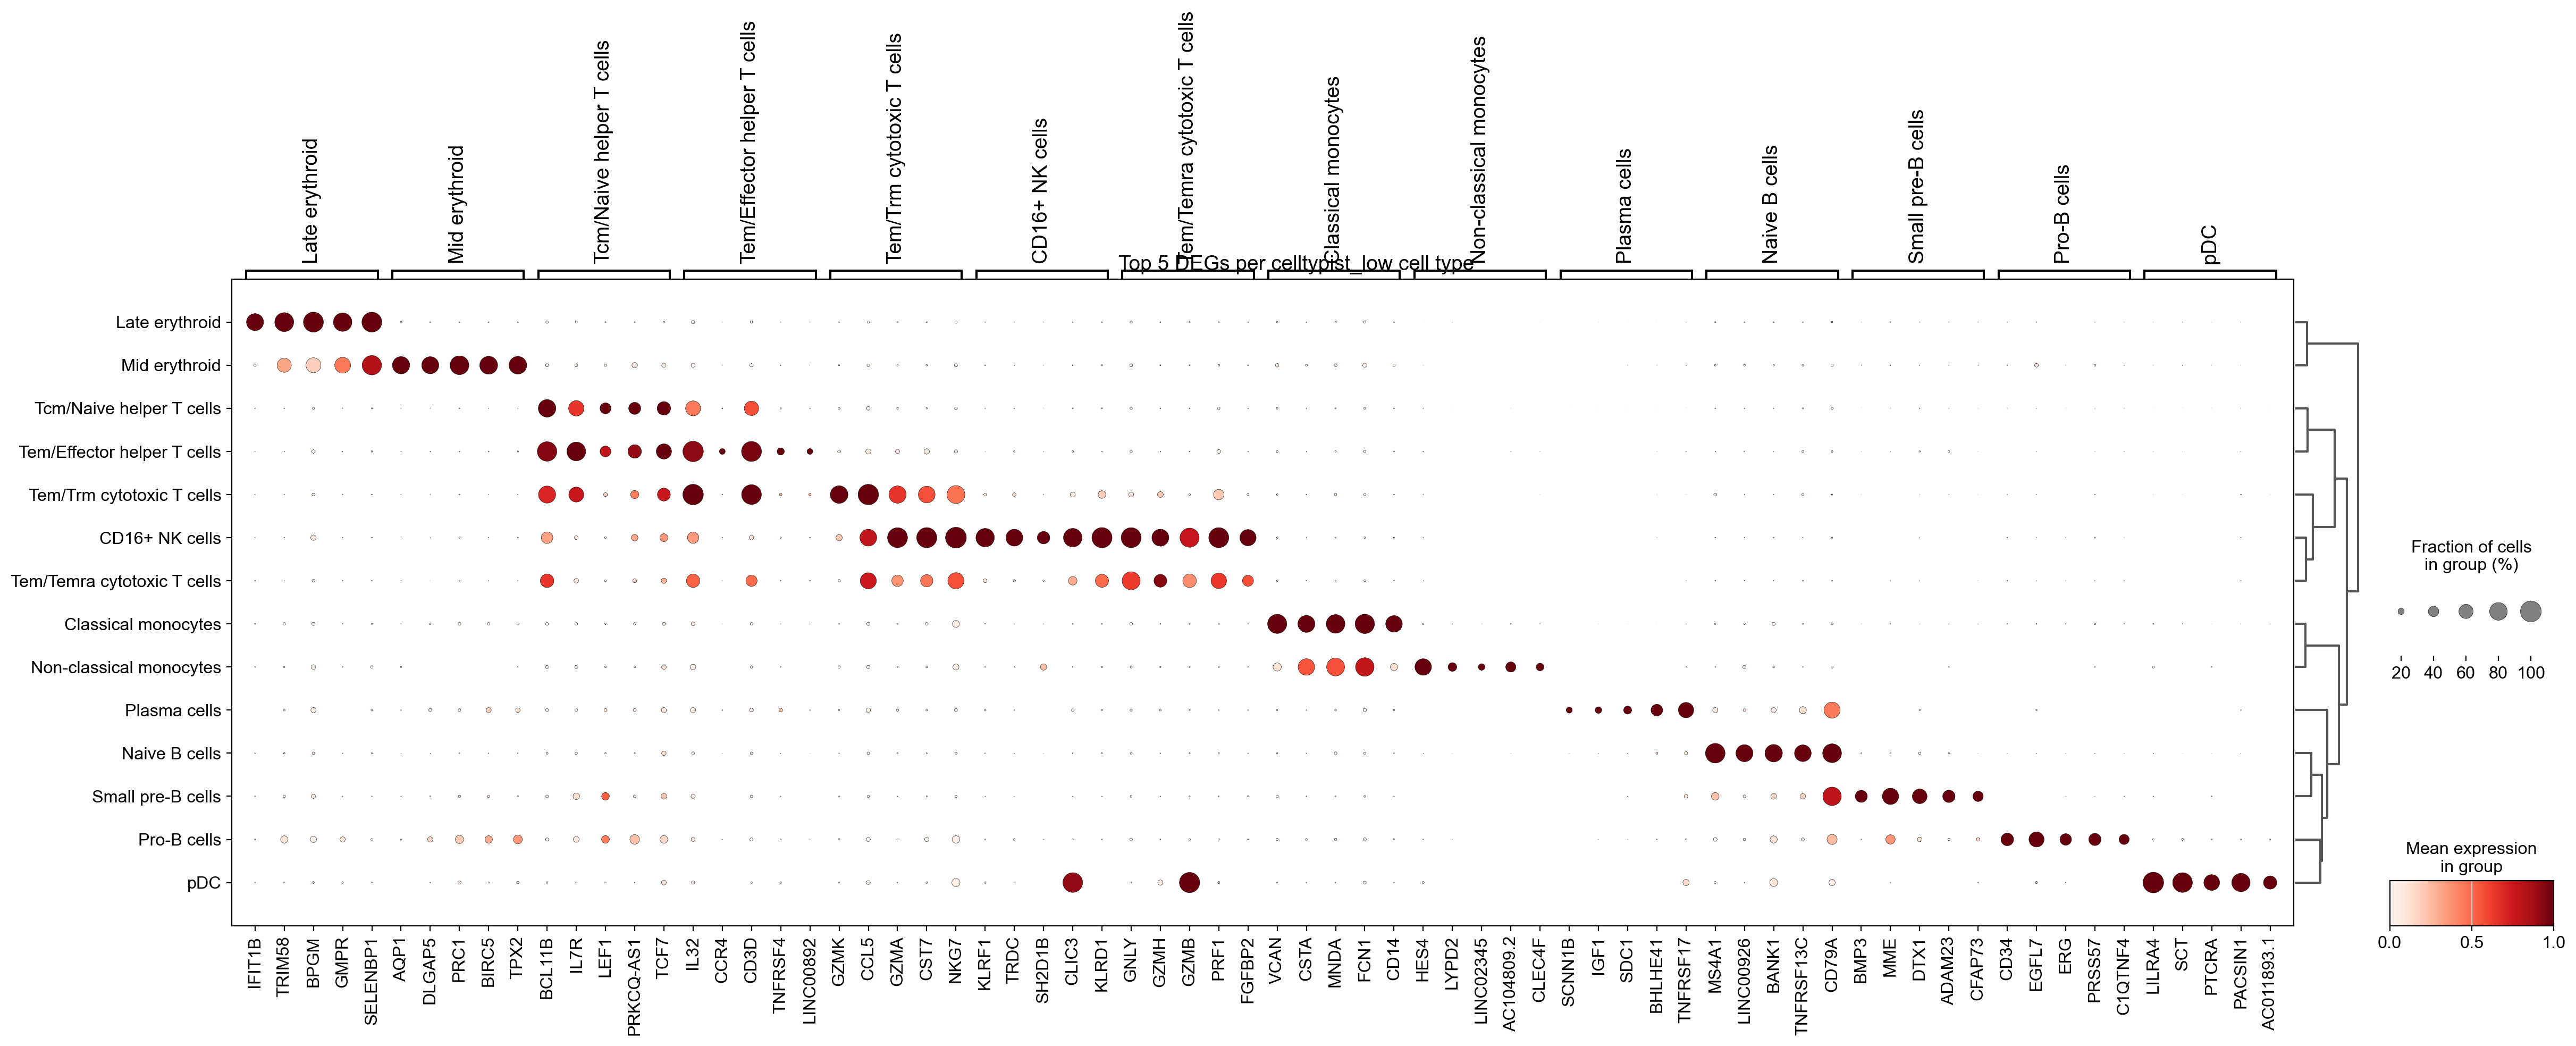

In [5]:
sc.pl.rank_genes_groups_dotplot(
    adata,
    groupby='celltypist_low',
    standard_scale='var',   # scale each gene 0-1 across groups for visual contrast
    n_genes=5,
    title='Top 5 DEGs per celltypist_low cell type',
    figsize=(28, 8),
)

## 6. Extract results as a tidy dataframe

In [6]:
cell_types = adata.obs['celltypist_low'].cat.categories.tolist()

deg_results = []
for ct in cell_types:
    df = sc.get.rank_genes_groups_df(
        adata,
        group=ct,
        pval_cutoff=0.05,
        log2fc_min=0.5,
    )
    df.insert(0, 'cell_type', ct)
    deg_results.append(df)

deg_df = pd.concat(deg_results, ignore_index=True)
print(f"Total significant DEGs (FDR < 0.05, log2FC ≥ 0.5): {len(deg_df)}")
deg_df.head(10)

Total significant DEGs (FDR < 0.05, log2FC ≥ 0.5): 62045


,cell_type,names,scores,logfoldchanges,pvals,pvals_adj,pct_nz_group,pct_nz_reference
0,CD16+ NK cells,KLRF1,90.605232,7.216455,0.0,0.0,0.851111,0.016913
1,CD16+ NK cells,TRDC,81.939972,6.479422,0.0,0.0,0.755556,0.017401
2,CD16+ NK cells,SH2D1B,78.391220,7.117460,0.0,0.0,0.506667,0.004885
3,CD16+ NK cells,CLIC3,69.514572,6.012185,0.0,0.0,0.857778,0.045549
4,CD16+ NK cells,KLRD1,69.234970,5.834236,0.0,0.0,0.957778,0.061058
5,CD16+ NK cells,GZMB,67.648994,6.297575,0.0,0.0,0.895556,0.055074
6,CD16+ NK cells,FCGR3A,66.689331,5.431792,0.0,0.0,0.775556,0.038161
7,CD16+ NK cells,SPON2,64.757507,5.687031,0.0,0.0,0.780000,0.043290
8,CD16+ NK cells,FGFBP2,64.322083,5.722088,0.0,0.0,0.720000,0.035291
9,CD16+ NK cells,XCL2,63.277302,5.437117,0.0,0.0,0.622222,0.025034


In [7]:
# DEG count per cell type
deg_df.groupby('cell_type').size().sort_values(ascending=False).rename('n_DEGs')

cell_type
Pro-B cells                    12068
Classical monocytes             7812
pDC                             7259
Non-classical monocytes         5719
Small pre-B cells               4348
Mid erythroid                   4253
CD16+ NK cells                  4068
Tem/Effector helper T cells     3638
Naive B cells                   3252
Plasma cells                    3105
Tem/Trm cytotoxic T cells       2985
Tcm/Naive helper T cells        1693
Tem/Temra cytotoxic T cells     1298
Late erythroid                   547
Name: n_DEGs, dtype: int64

## 7. Top 5 DEGs per cell type (names only)

In [8]:
for ct in cell_types:
    top5 = sc.get.rank_genes_groups_df(adata, group=ct).head(5)['names'].tolist()
    print(f"{ct}: {', '.join(top5)}")

CD16+ NK cells: KLRF1, TRDC, SH2D1B, CLIC3, KLRD1
Classical monocytes: VCAN, CSTA, MNDA, FCN1, CD14
Late erythroid: IFIT1B, TRIM58, BPGM, GMPR, SELENBP1
Mid erythroid: AQP1, DLGAP5, PRC1, BIRC5, TPX2
Naive B cells: MS4A1, LINC00926, BANK1, TNFRSF13C, CD79A
Non-classical monocytes: HES4, LYPD2, LINC02345, AC104809.2, CLEC4F
Plasma cells: SCNN1B, IGF1, SDC1, BHLHE41, TNFRSF17
Pro-B cells: CD34, EGFL7, ERG, PRSS57, C1QTNF4
Small pre-B cells: BMP3, MME, DTX1, ADAM23, CFAP73
Tcm/Naive helper T cells: BCL11B, IL7R, LEF1, PRKCQ-AS1, TCF7
Tem/Effector helper T cells: IL32, CCR4, CD3D, TNFRSF4, LINC00892
Tem/Temra cytotoxic T cells: GNLY, GZMH, GZMB, PRF1, FGFBP2
Tem/Trm cytotoxic T cells: GZMK, CCL5, GZMA, CST7, NKG7
pDC: LILRA4, SCT, PTCRA, PACSIN1, AC011893.1


## 8. UMAP coloured by top marker of each cell type

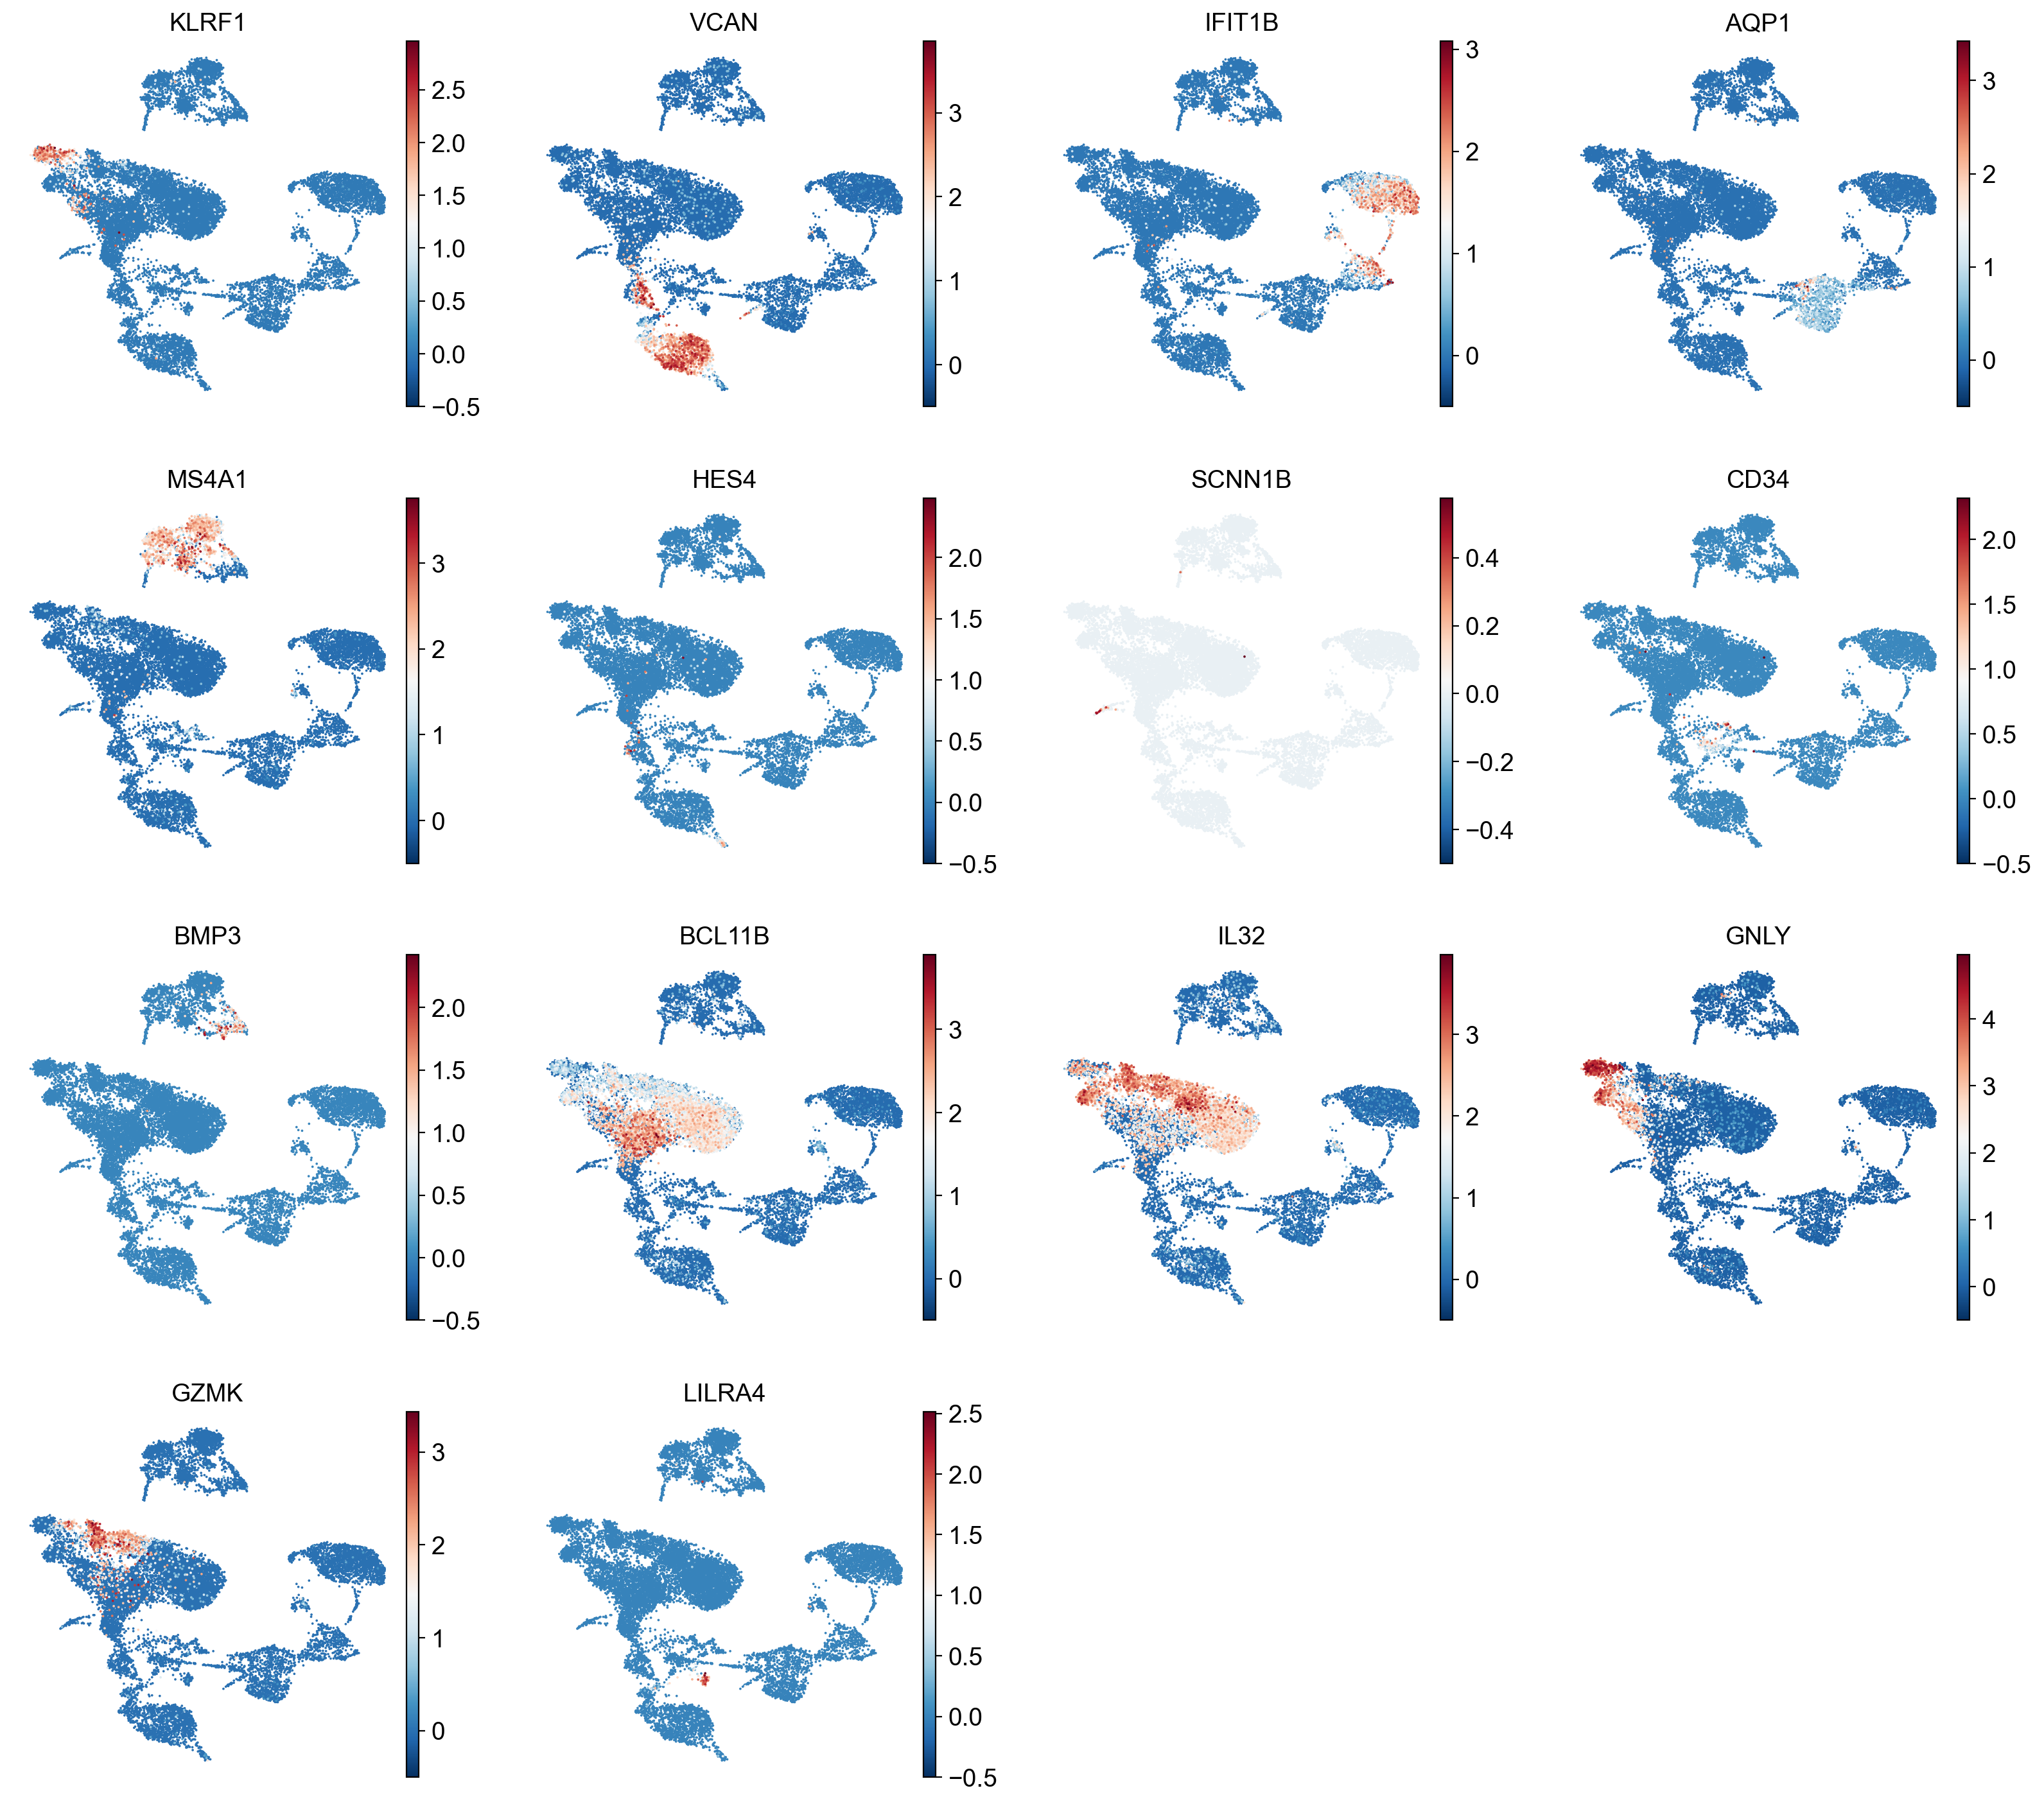

In [9]:
top_markers = []
for ct in cell_types:
    df = sc.get.rank_genes_groups_df(adata, group=ct)
    # pick first gene present in adata.var_names
    for g in df['names']:
        if g in adata.var_names:
            top_markers.append(g)
            break

sc.pl.umap(
    adata,
    color=top_markers,
    ncols=4,
    color_map='RdBu_r',
    vmin=-0.5,
)

## 9. Save DEG table

In [10]:
deg_df.to_csv('deg_celltypist_low.csv', index=False)
print("Saved: deg_celltypist_low.csv")

Saved: deg_celltypist_low.csv


> **Note on p-value interpretation**: individual cells are treated as independent observations, which inflates statistical power and makes p-values appear artificially low. For publication-grade comparisons across conditions/samples, use pseudo-bulk DEG methods (e.g. `pydeseq2`) that aggregate counts per donor before testing.